<a href="https://colab.research.google.com/github/Priyankaverma2024/Chemical-Component-Analysis/blob/main/Analysis_Of_Chemical_Components.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Cosmetics, chemicals... it's complicated
<p>Whenever I want to try a new cosmetic item, it's so difficult to choose. It's actually more than difficult. It's sometimes scary because new items that I've never tried end up giving me skin trouble. We know the information we need is on the back of each product, but it's really hard to interpret those ingredient lists unless you're a chemist. You may be able to relate to this situation.</p>
<p><img src="https://assets.datacamp.com/production/project_695/img/image_1.png" style="width:600px;height:400px;"></p>
<p>So instead of buying and hoping for the best, why don't we use data science to help us predict which products may be good fits for us? In this notebook, we are going to create a content-based recommendation system where the 'content' will be the chemical components of cosmetics. Specifically, we will process ingredient lists for 1472 cosmetics on Sephora via <a href="https://en.wikipedia.org/wiki/Word_embedding">word embedding</a>, then visualize ingredient similarity using a machine learning method called t-SNE and an interactive visualization library called Bokeh. Let's inspect our data first.</p>

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [ ]:
df = pd.read_csv('/content/cosmetics.csv')
df.head(5)

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1


In [ ]:
# find the shape of our cosmetic dataset

df.shape

(1472, 11)

In [ ]:
# how many columns we have inside the whole dataset
df.columns

Index(['Label', 'Brand', 'Name', 'Price', 'Rank', 'Ingredients', 'Combination',
       'Dry', 'Normal', 'Oily', 'Sensitive'],
      dtype='object')

In [ ]:
# To check is there any null values present inside the dataset
df.isnull().sum()

,0
Label,0
Brand,0
Name,0
Price,0
Rank,0
Ingredients,0
Combination,0
Dry,0
Normal,0
Oily,0


In [ ]:
 # To get the basic information about the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Label        1472 non-null   object 
 1   Brand        1472 non-null   object 
 2   Name         1472 non-null   object 
 3   Price        1472 non-null   int64  
 4   Rank         1472 non-null   float64
 5   Ingredients  1472 non-null   object 
 6   Combination  1472 non-null   int64  
 7   Dry          1472 non-null   int64  
 8   Normal       1472 non-null   int64  
 9   Oily         1472 non-null   int64  
 10  Sensitive    1472 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 126.6+ KB


In [ ]:
# Statistical data discription
df.describe()

,Price,Rank,Combination,Dry,Normal,Oily,Sensitive
count,1472.000000,1472.000000,1472.00000,1472.000000,1472.000000,1472.000000,1472.000000
mean,55.584239,4.153261,0.65625,0.614130,0.652174,0.607337,0.513587
std,45.014429,0.633918,0.47512,0.486965,0.476442,0.488509,0.499985
min,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,4.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,42.500000,4.300000,1.00000,1.000000,1.000000,1.000000,1.000000
75%,68.000000,4.500000,1.00000,1.000000,1.000000,1.000000,1.000000
max,370.000000,5.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# find types of products and their count
df['Label'].value_counts()

,count
Label,
Moisturizer,298
Cleanser,281
Face Mask,266
Treatment,248
Eye cream,209
Sun protect,170


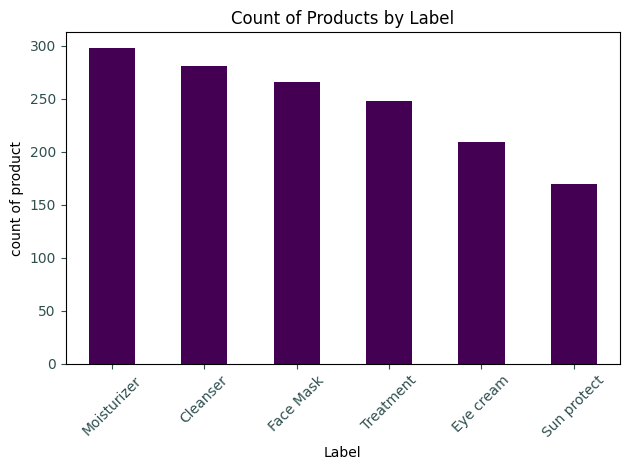

In [ ]:
# visualization of product using bar graph
ax = df['Label'].value_counts().plot(kind='bar', cmap='viridis')
ax.set_ylabel('count of product')
ax.tick_params(axis='x', rotation=45, colors='darkslategray', labelsize=10)
ax.tick_params(axis='y', colors='darkslategray', labelsize=10)
plt.title('Count of Products by Label') # Adding a title for clarity
plt.tight_layout() # Adjust layout to prevent labels from overlapping


## 2. Focus on one product category and one skin type
<p>There are six categories of product in our data (<strong><em>moisturizers, cleansers, face masks, eye creams</em></strong>, and <strong><em>sun protection</em></strong>) and there are five different skin types (<strong><em>combination, dry, normal, oily</em></strong> and <strong><em>sensitive</em></strong>). Because individuals have different product needs as well as different skin types, let's set up our workflow so its outputs (a t-SNE model and a visualization of that model) can be customized. For the example in this notebook, let's focus in on moisturizers for those with dry skin by filtering the data accordingly.</p>

In [ ]:
# create filter for moisturizers
moisturizers = df['Label'] == 'Moisturizers'

In [ ]:
moisturizers = df[df['Label'].str.contains('Moisturizer')]

In [ ]:
display(moisturizers.head())

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1


In [ ]:
moisturizers.shape

(298, 11)

In [ ]:
# create filter moisturizer for dry skin type  save in moisturizer_dry
moisturizers_dry = moisturizers[moisturizers['Dry'] == 1]

In [ ]:
moisturizers_dry.shape

(190, 11)

In [ ]:
moisturizers_dry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, 0 to 297
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Label        190 non-null    object 
 1   Brand        190 non-null    object 
 2   Name         190 non-null    object 
 3   Price        190 non-null    int64  
 4   Rank         190 non-null    float64
 5   Ingredients  190 non-null    object 
 6   Combination  190 non-null    int64  
 7   Dry          190 non-null    int64  
 8   Normal       190 non-null    int64  
 9   Oily         190 non-null    int64  
 10  Sensitive    190 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 17.8+ KB


In [ ]:
# reset index

moisturizers_dry = moisturizers_dry.reset_index(drop=True)
display(moisturizers_dry.head(20))

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1
5,Moisturizer,DRUNK ELEPHANT,Lala Retro™ Whipped Cream,60,4.2,"Water, Glycerin, Caprylic/ Capric Triglyceride...",1,1,1,1,0
6,Moisturizer,DRUNK ELEPHANT,Virgin Marula Luxury Facial Oil,72,4.4,100% Unrefined Sclerocraya Birrea (Marula) Ker...,1,1,1,1,0
7,Moisturizer,KIEHL'S SINCE 1851,Ultra Facial Cream,29,4.4,"Water, Glycerin, Cyclohexasiloxane, Squalane, ...",1,1,1,1,1
8,Moisturizer,KIEHL'S SINCE 1851,Midnight Recovery Concentrate,47,4.4,Caprylic/Capric Triglyceride Dicaprylyl Carbon...,1,1,1,1,1
9,Moisturizer,SUNDAY RILEY,Luna Sleeping Night Oil,105,4.1,"Persea Gratissima (Extra Virgin, Cold Pressed ...",1,1,1,1,1


# TASK 3
**Tokenizing the ingredients**

To get to our end goul of comparing ingredients in each product , we first need to do some preprocessing task and book keeping of the actual words in eachproduct's ingredient list.The first step wil be tokenizing the list of ingredients column.After splitting them into tokens, we will make a binary bag of bwords. then we will create a dictionary with the tokens,ingredient_idx , which wll have the following format

In [ ]:
# Initialize dictionary,lists and initial index
corpus = []
ingredient_idx = {}
idx = 0


# for loop for tokenization
for i in range(len(moisturizers_dry)):
    ingredients = moisturizers_dry['Ingredients'][i]
    ingredients_lower = ingredients.lower()
    tokens = ingredients_lower.split(',')
    corpus.append(tokens) # Corrected to append the list of tokens
    for ingredient in tokens:
        # Strip whitespace from the ingredient string before using it as a key
        cleaned_ingredient = ingredient.strip()
        if cleaned_ingredient not in ingredient_idx:
            ingredient_idx[cleaned_ingredient] = idx # Corrected: use cleaned_ingredient as key
            idx += 1
# check the result
print("The index for decyl oleate is ", ingredient_idx['decyl oleate'])

The index for decyl oleate is  25


## 4. Initializing a document-term matrix (DTM)
<p>The next step is making a document-term matrix (DTM). Here each cosmetic product will correspond to a document, and each chemical composition will correspond to a term. This means we can think of the matrix as a <em>“cosmetic-ingredient”</em> matrix. The size of the matrix should be as the picture shown below.
<img src="https://assets.datacamp.com/production/project_695/img/image_2.PNG" style="width:600px;height:250px;">
To create this matrix, we'll first make an empty matrix filled with zeros. The length of the matrix is the total number of cosmetic products in the data. The width of the matrix is the total number of ingredients. After initializing this empty matrix, we'll fill it in the following tasks. </p>

In [ ]:
# get the number of items and tokens
M = len(corpus)
N = len(ingredient_idx)


# Initialize a matrix of zeros
A = np.zeros((M, N))

# TASK 5
 Creating a counter function
<p>Before we can fill the matrix, let's create a function to count the tokens (i.e., an ingredients list) for each row. Our end goal is to fill the matrix with 1 or 0: if an ingredient is in a cosmetic, the value is 1. If not, it remains 0. The name of this function, <code>oh_encoder</code>, will become clear next.</p>


In [ ]:
# Define the oh_encoder function
def oh_encoder(tokens):
    x = np.zeros(len(ingredient_idx))
    for ingredient in tokens:
        # Get the index for each ingredient
        idx = ingredient_idx[ingredient.strip()]
        # Put 1 at the corresponding indices
        x[idx] = 1
    return x

# TASK 6

#The Cosmetic-Ingredient matrix!
<p>Now we'll apply the <code>oh_encoder()</code> functon to the tokens in <code>corpus</code> and set the values at each row of this matrix. So the result will tell us what ingredients each item is composed of. For example, if a cosmetic item contains <em>water, niacin, decyl aleate</em> and <em>sh-polypeptide-1</em>, the outcome of this item will be as follows.
<img src="https://assets.datacamp.com/production/project_695/img/image_3.PNG" style="width:800px;height:400px;">
This is what we called one-hot encoding. By encoding each ingredient in the items, the <em>Cosmetic-Ingredient</em> matrix will be filled with binary values. </p>

In [ ]:
# Make a document-term matrix
i = 0
for tokens in corpus:
    A[i, :] = oh_encoder(tokens)
    i += 1

# TASK 7
**Dimension reduction with t-SNE**

The dimensions of the existing matrix is (190, 2233), which means there are 2233 features in our data. For visualization, we should downsize this into two dimensions. We'll use t-SNE for reducing the dimension of the data here.
T- DISTRIBUTION STOCHASTIC NEIGHBOUR EMBEDDING(t-SNE) is a
nonlinear dimensionality reduction technique that is well-suited for embedding high-dimensional data for visualization in a low-dimensional space of two or three dimensions. Specifically, this technique can reduce the dimension of data while keeping the similarities between the instances. This enables us to make a plot on the coordinate plane, which can be said as vectorizing. All of these cosmetic items in our data will be vectorized into two-dimensional coordinates, and the distances between the points will indicate the similarities between the items.

In [ ]:
# Dimension reduction with t-SNE
model = TSNE(n_components=2, random_state=0)
tsne_features = model.fit_transform(A)

# Make X, Y columns
moisturizers_dry['X'] = tsne_features[:, 0]
moisturizers_dry['Y'] = tsne_features[:, 1]

#TASK 8
**Let's map the items with Bokeh**

 now ready to start creating our plot. With the t-SNE values, we can plot all our items on the coordinate plane. And the coolest part here is that it will also show us the name, the brand, the price and the rank of each item. Let's make a scatter plot using Bokeh and add a hover tool to show that information. Note that we won't display the plot yet as we will make some more additions to it.

In [ ]:
from bokeh.io import show, output_notebook, push_notebook
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import Plasma10 # Import the Plasma10 palette
output_notebook()

# Make a source and a scatter plot
source = ColumnDataSource(moisturizers_dry)

plot = figure(x_axis_label = 't-SNE X', # Label for the x-axis
              y_axis_label = 't-SNE Y', # Label for the y-axis
              width = 500, height = 400)
             # tools=[hover, 'pan', 'wheel_zoom', 'box_zoom', 'reset', 'save'])

plot.scatter(x = 'X',
             y = 'Y',
             source = source,
             size = 10, color = Plasma10[0], alpha = .8) # Changed color to the first color from Plasma10


GlyphRenderer(id='p1046', ...)

In [ ]:
# Display the plot without tooltip
show(plot)

Document-Term Matrix (DTM), which in our case, is a 'Cosmetic-Ingredient' matrix.

Here's what it means:

Documents: Each cosmetic product will be considered a 'document'.
Terms: Each unique chemical ingredient will be a 'term'.
The matrix will have dimensions where the number of rows equals the total number of cosmetic products, and the number of columns equals the total number of unique ingredients. Initially, this matrix will be filled with zeros. The subsequent steps will involve populating this matrix to indicate the presence or absence of each ingredient in each cosmetic product.

# next code is optional for hover tool

## 9. Adding a hover tool
Why don't we add a hover tool? Adding a hover tool allows us to check the information of each item whenever the cursor is directly over a glyph. We'll add tooltips with each product's name, brand, price, and rank (i.e., rating)

In [ ]:
# Create a HoverTool object for tooltip
hover = HoverTool(tooltips = [("Name", "@Name"),
                              ("Brand", "@Brand"),
                              ("Price", "@Price{$0.00}"),
                              ("Rank", "@Rank")])
plot.add_tools(hover)

## 10. Mapping the cosmetic items
<p>Finally, it's show time! Let's see how the map we've made looks like. Each point on the plot corresponds to the cosmetic items. Then what do the axes mean here? The axes of a t-SNE plot aren't easily interpretable in terms of the original data. Like mentioned above, t-SNE is a visualizing technique to plot high-dimensional data in a low-dimensional space. Therefore, it's not desirable to interpret a t-SNE plot quantitatively.</p>
<p>Instead, what we can get from this map is the distance between the points (which items are close and which are far apart). The closer the distance between the two items is, the more similar the composition they have. Therefore this enables us to compare the items without having any chemistry background.</p>

In [ ]:
# plot the map with hover tool
#
show(plot)

# Insight
On the t-SNE map, the distance between points is crucial for understanding ingredient similarity:

Closer points mean that the cosmetic items are more similar in their chemical composition.
Further apart points indicate that the cosmetic items have less similar ingredient lists.
So, if two products appear close together on the map, you can infer that they share a high degree of ingredient commonality, even if their brands or names are different. This allows for a visual comparison of cosmetics based purely on their ingredient profiles.


## 11. Comparing two products
<p>Since there are so many cosmetics and so many ingredients, the plot doesn't have many super obvious patterns that simpler t-SNE plots can have (<a href="https://campus.datacamp.com/courses/unsupervised-learning-in-python/visualization-with-hierarchical-clustering-and-t-sne?ex=10">example</a>). Our plot requires some digging to find insights, but that's okay!</p>
<p>Say we enjoyed a specific product, there's an increased chance we'd enjoy another product that is similar in chemical composition.  Say we enjoyed AmorePacific's <a href="https://www.sephora.com/product/color-control-cushion-compact-broad-spectrum-spf-50-P378121">Color Control Cushion Compact Broad Spectrum SPF 50+</a>. We could find this product on the plot and see if a similar product(s) exist. And it turns out it does! If we look at the points furthest left on the plot, we see  LANEIGE's <a href="https://www.sephora.com/product/bb-cushion-hydra-radiance-P420676">BB Cushion Hydra Radiance SPF 50</a> essentially overlaps with the AmorePacific product. By looking at the ingredients, we can visually confirm the compositions of the products are similar (<em>though it is difficult to do, which is why we did this analysis in the first place!</em>), plus LANEIGE's version is $22 cheaper and actually has higher ratings.</p>
<p>It's not perfect, but it's useful. In real life, we can actually use our little ingredient-based recommendation engine help us make educated cosmetic purchase choices.</p>

In [ ]:
# Print the ingredients of two similar cosmetics
cosmetic_1 = moisturizers_dry[moisturizers_dry['Name'] == "Color Control Cushion Compact Broad Spectrum SPF 50+"]
cosmetic_2 = moisturizers_dry[moisturizers_dry['Name'] == "BB Cushion Hydra Radiance SPF 50"]

# Display each item's data and ingredients
display(cosmetic_1)
print(cosmetic_1.Ingredients.values)
display(cosmetic_2)
print(cosmetic_2.Ingredients.values)

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive,X,Y
45,Moisturizer,AMOREPACIFIC,Color Control Cushion Compact Broad Spectrum S...,60,4.0,"Phyllostachis Bambusoides Juice, Cyclopentasil...",1,1,1,1,1,111.234138,-128.422043


['Phyllostachis Bambusoides Juice, Cyclopentasiloxane, Cyclohexasiloxane, Peg-10 Dimethicone, Phenyl Trimethicone, Butylene Glycol, Butylene Glycol Dicaprylate/Dicaprate, Alcohol, Arbutin, Lauryl Peg-9 Polydimethylsiloxyethyl Dimethicone, Acrylates/Ethylhexyl Acrylate/Dimethicone Methacrylate Copolymer, Polyhydroxystearic Acid, Sodium Chloride, Polymethyl Methacrylate, Aluminium Hydroxide, Stearic Acid, Disteardimonium Hectorite, Triethoxycaprylylsilane, Ethylhexyl Palmitate, Lecithin, Isostearic Acid, Isopropyl Palmitate, Phenoxyethanol, Polyglyceryl-3 Polyricinoleate, Acrylates/Stearyl Acrylate/Dimethicone Methacrylate Copolymer, Dimethicone, Disodium Edta, Trimethylsiloxysilicate, Ethylhexyglycerin, Dimethicone/Vinyl Dimethicone Crosspolymer, Water, Silica, Camellia Japonica Seed Oil, Camillia Sinensis Leaf Extract, Caprylyl Glycol, 1,2-Hexanediol, Fragrance, Titanium Dioxide, Iron Oxides (Ci 77492, Ci 77491, Ci77499).']


,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive,X,Y
55,Moisturizer,LANEIGE,BB Cushion Hydra Radiance SPF 50,38,4.3,"Water, Cyclopentasiloxane, Zinc Oxide (CI 7794...",1,1,1,1,1,117.27832,-143.132278


['Water, Cyclopentasiloxane, Zinc Oxide (CI 77947), Ethylhexyl Methoxycinnamate, PEG-10 Dimethicone, Cyclohexasiloxane, Phenyl Trimethicone, Iron Oxides (CI 77492), Butylene Glycol Dicaprylate/Dicaprate, Niacinamide, Lauryl PEG-9 Polydimethylsiloxyethyl Dimethicone, Acrylates/Ethylhexyl Acrylate/Dimethicone Methacrylate Copolymer, Titanium Dioxide (CI 77891 , Iron Oxides (CI 77491), Butylene Glycol, Sodium Chloride, Iron Oxides (CI 77499), Aluminum Hydroxide, HDI/Trimethylol Hexyllactone Crosspolymer, Stearic Acid, Methyl Methacrylate Crosspolymer, Triethoxycaprylylsilane, Phenoxyethanol, Fragrance, Disteardimonium Hectorite, Caprylyl Glycol, Yeast Extract, Acrylates/Stearyl Acrylate/Dimethicone Methacrylate Copolymer, Dimethicone, Trimethylsiloxysilicate, Polysorbate 80, Disodium EDTA, Hydrogenated Lecithin, Dimethicone/Vinyl Dimethicone Crosspolymer, Mica (CI 77019), Silica, 1,2-Hexanediol, Polypropylsilsesquioxane, Chenopodium Quinoa Seed Extract, Magnesium Sulfate, Calcium Chloride

The above code has successfully identified and displayed the data for two similar cosmetic products: "Color Control Cushion Compact Broad Spectrum SPF 50+" and "BB Cushion Hydra Radiance SPF 50".

**As we can see from the output, despite different brands and slight variations in price and rank, their detailed ingredient lists are quite similar. This confirms the power of our t-SNE based analysis, which grouped these products closely together on the plot due to their similar chemical compositions. This kind of comparison can be very useful for finding alternative products or understanding why certain products are effective**.





